In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
### Workflow
1. Preparing and loading data
2. Building the model
3. Fitting the model to data
4. Predictions and model evaluation
5. Saving and loading models
6. Orchestrating the above 

---
### 1. Preparing and loading data

In [2]:
data = pd.read_csv("data/house_prices.csv")

data.head()

,size_sqft,price
0,500,155000
1,600,185000
2,700,215000
3,800,245000
4,900,275000


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[["size_sqft"]] # Source 2D - Treated as a DF
y = data["price"] # Target 1D - Treated as vector

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test = scaler_y.transform(y_test.values.reshape(-1, 1))

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

---
### Visualise

In [4]:
def plot_predictions(X_train, y_train, X_test, y_test, predictions=None):
    # Training Data
    plt.scatter(X_train, y_train, label="Training Data", c="b")

    # Testing Data
    plt.scatter(X_test, y_test, label="Testing Data", c="g")

    # Predicions
    if predictions is not None:
        plt.scatter(X_test, predictions, label="Predictions", c="r")
    
    plt.legend()

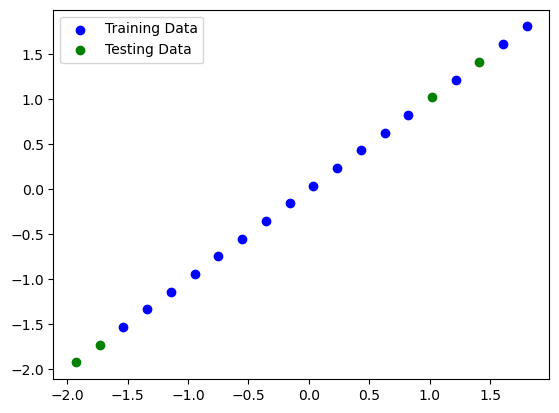

In [5]:
plot_predictions(X_train, y_train, X_test, y_test)

---
### 2. Building the model

In [6]:
# This library contains all building blocks for neural networks
from torch import nn

In [7]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(
            torch.randn(
                1,
                requires_grad=True,
                dtype=torch.float
            )
        )

        self.bias = nn.Parameter(
            torch.randn(
                1,
                requires_grad=True,
                dtype=torch.float
            )
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (self.weights * x) + self.bias

In [8]:
torch.manual_seed(42)

model_0 = LinearRegression()
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [9]:
# Predictions
with torch.inference_mode():
    y_pred = model_0(X_test)

y_pred

tensor([[-0.5203],
        [ 0.6043],
        [ 0.4720],
        [-0.4542]])

In [10]:
y_test

tensor([[-1.9280],
        [ 1.4122],
        [ 1.0193],
        [-1.7315]])

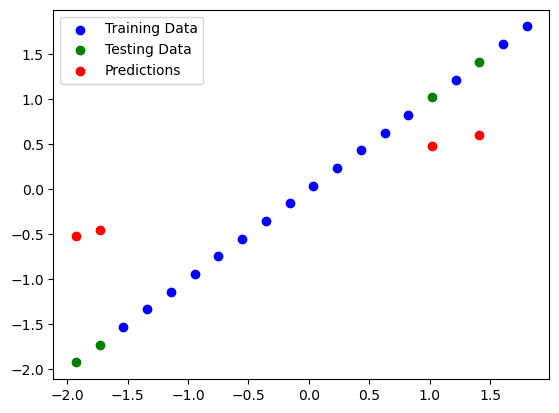

In [11]:
plot_predictions(X_train, y_train, X_test, y_test, predictions=y_pred)

### 3. Model Training

In [12]:
# Loss Function & Optimizer
loss_fn = nn.L1Loss()

# Optmizer (Stochastic Gradient Decent)
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.001
)

In [13]:
torch.manual_seed(42)
# Training Loop
epochs = 100

training_loss = []
testing_loss = []

for epoch in range(epochs):
    # set the model to training mode
    model_0.train()

    # Forward pass
    y_pred = model_0(X_train)

    # Loss
    loss = loss_fn(y_pred, y_train)
    training_loss.append(loss.item())

    # Optimizer zero grad
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Optimizer (SGD)
    optimizer.step()

    model_0.eval()

    # Evaluation Loop
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)
        testing_loss.append(test_loss.item())
        if epoch % 10 == 0:
            print(f"Epoch : {epoch} | Loss : {loss} | Test Loss : {test_loss}")
    

Epoch : 0 | Loss : 0.5750977396965027 | Test Loss : 1.008779764175415
Epoch : 10 | Loss : 0.5678393244743347 | Test Loss : 0.9959466457366943
Epoch : 20 | Loss : 0.5605809092521667 | Test Loss : 0.9831135272979736
Epoch : 30 | Loss : 0.553322434425354 | Test Loss : 0.9702805280685425
Epoch : 40 | Loss : 0.546064019203186 | Test Loss : 0.9574474096298218
Epoch : 50 | Loss : 0.5388056039810181 | Test Loss : 0.9446142911911011
Epoch : 60 | Loss : 0.5315471887588501 | Test Loss : 0.9317811727523804
Epoch : 70 | Loss : 0.5242887735366821 | Test Loss : 0.9189481735229492
Epoch : 80 | Loss : 0.5170302987098694 | Test Loss : 0.9061150550842285
Epoch : 90 | Loss : 0.5097718238830566 | Test Loss : 0.8932819366455078


In [14]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.4210])), ('bias', tensor([0.1163]))])

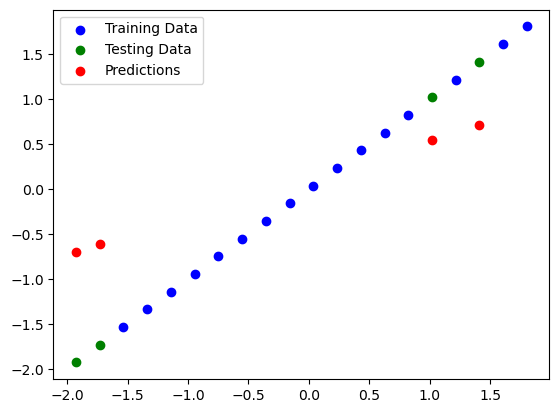

In [15]:
with torch.inference_mode():
    y_pred = model_0(X_test)
    
plot_predictions(X_train, y_train, X_test, y_test, predictions=y_pred)

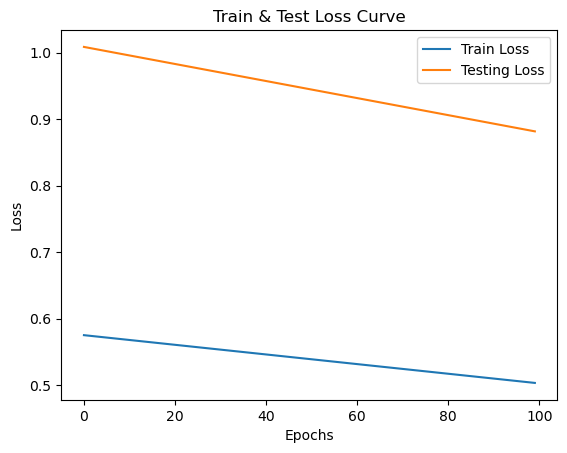

In [16]:
plt.plot(range(epochs), training_loss, label="Train Loss")
plt.plot(range(epochs), testing_loss, label="Testing Loss")

plt.title("Train & Test Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

### 4.Saving the model

In [17]:
from pathlib import Path
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = Path("model_0.pth")
FILE_PATH = MODEL_DIR / MODEL_NAME

print(f"Saving {FILE_PATH}")
torch.save(obj=model_0.state_dict(), f=FILE_PATH)

Saving models/model_0.pth


### Loading The model

In [18]:
loaded_model_0 = LinearRegression()

In [19]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [20]:
loaded_model_0.load_state_dict(torch.load(FILE_PATH))

<All keys matched successfully>

In [21]:
loaded_pred = loaded_model_0(X_test)

In [23]:
pred = model_0(X_test)

In [24]:
loaded_pred == pred

tensor([[True],
        [True],
        [True],
        [True]])